PURUSHOTHAM GS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dataset = pd.read_csv('Salary_Data.csv')
dataset

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [ ]:
x=dataset.iloc[:,0:1].values
y=dataset.iloc[:,-1].values
print(x)
print(y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)
print(x_train)

[[ 2.9]
 [ 5.1]
 [ 3.2]
 [ 4.5]
 [ 8.2]
 [ 6.8]
 [ 1.3]
 [10.5]
 [ 3. ]
 [ 2.2]
 [ 5.9]
 [ 6. ]
 [ 3.7]
 [ 3.2]
 [ 9. ]
 [ 2. ]
 [ 1.1]
 [ 7.1]
 [ 4.9]
 [ 4. ]]


In [ ]:
print(dataset.shape)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(30, 2)
(20, 1)
(10, 1)
(20,)
(10,)


In [ ]:
x_mean=np.mean(x_train)
y_mean=np.mean(y_train)
print(x_mean)
print(y_mean)

4.7299999999999995
71022.5


In [ ]:
from os import devnull
n=len(x_train)
num,den=0,0

for i in range(n):
  num+=(x_train[i]-x_mean)*(y_train[i]-y_mean)
  den+=(x_train[i]-x_mean)**2

b1=num/den
b0=y_mean-(b1*x_mean)
print('b0',b0)
print('b1',b1)

b0 [26816.19224403]
b1 [9345.94244312]


In [ ]:
y_pred_code=b0+b1*x_test
print(y_pred_code)

[[ 40835.10590871]
 [123079.39940819]
 [ 65134.55626083]
 [ 63265.36777221]
 [115602.64545369]
 [108125.8914992 ]
 [116537.23969801]
 [ 64199.96201652]
 [ 76349.68719258]
 [100649.1375447 ]]


In [ ]:
#mean square method
n1=len(y_test)
mse=0
for i in range(n1):
  mse+=(y_pred_code[i]-y_test[i])**2

mse=mse/n1
print(mse)

#root mean square error
rmse=np.sqrt(mse)
print(rmse)


[21026037.3295113]
[4585.41572047]


In [ ]:
#Creating an object of the algorithm/model
x=dataset.iloc[:,0].values
y=dataset.iloc[:,-1].values
print(x)
print(y)
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x_train,y_train)

[ 1.1  1.3  1.5  2.   2.2  2.9  3.   3.2  3.2  3.7  3.9  4.   4.   4.1
  4.5  4.9  5.1  5.3  5.9  6.   6.8  7.1  7.9  8.2  8.7  9.   9.5  9.6
 10.3 10.5]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


LinearRegression()

In [ ]:
y_pred=reg.predict(x_test)
print(y_pred)

[ 40835.10590871 123079.39940819  65134.55626083  63265.36777221
 115602.64545369 108125.8914992  116537.23969801  64199.96201652
  76349.68719258 100649.1375447 ]


In [ ]:
print('Intercept',reg.intercept_)
print('Slope',reg.coef_)

Intercept 26816.192244031183
Slope [9345.94244312]


In [ ]:
#Evaluation
from sklearn import metrics
print('Mean absolute error')
print(metrics.mean_absolute_error(y_test,y_pred))

Mean absolute error
3426.4269374307078


In [ ]:
from sklearn import metrics
print('mean abslute error',metrics.mean_absolute_error(y_test,y_pred))
print('mean squared error',metrics.mean_squared_error(y_test,y_pred))
print('root mean squared error: ',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

mean abslute error 3426.4269374307078
mean squared error 21026037.329511296
root mean squared error:  4585.4157204675885


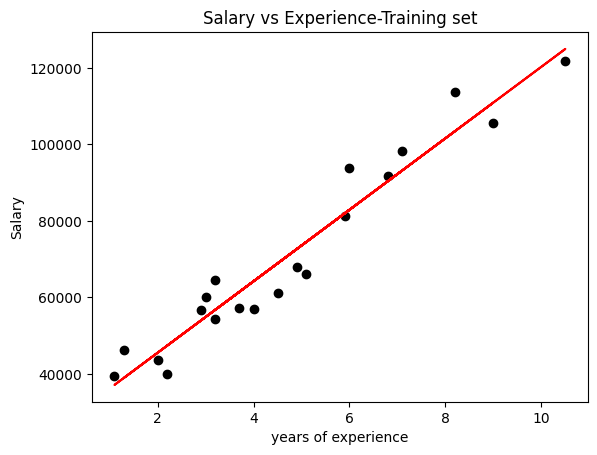

In [ ]:
import matplotlib.pyplot as plt
#Visualization
plt.scatter(x_train,y_train,color='black')
plt.plot(x_train,reg.predict(x_train),color='red')
plt.title('Salary vs Experience-Training set')
plt.xlabel('years of experience')
plt.ylabel('Salary')
plt.show()

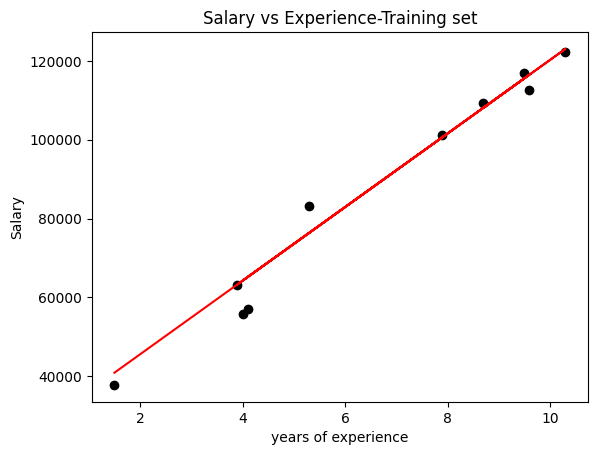

In [ ]:
plt.scatter(x_test,y_test,color='black')
plt.plot(x_test,reg.predict(x_test),color='red')
plt.title('Salary vs Experience-Training set')
plt.xlabel('years of experience')
plt.ylabel('Salary')
plt.show()